T		g4(T)
  0.00	0.916200
  0.10	0.923134
  0.20	0.854105
  0.30	0.769275
  0.40	0.708863
  0.50	0.693141
  0.60	0.722438
  0.70	0.777135
  0.80	0.817669
  0.90	0.784531


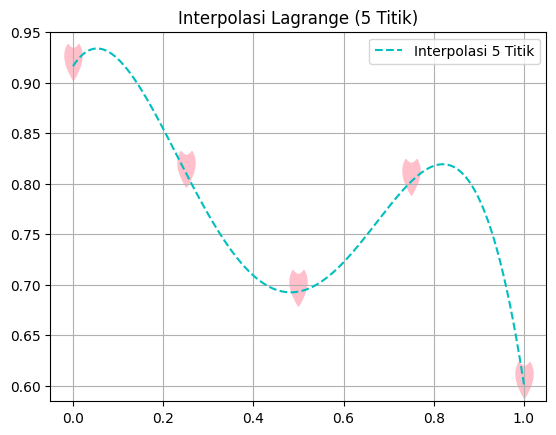

g4(  0.30) = 0.769508

Persamaan Lagrange untuk 5 titik:
- 34.5984 T \left(T - 1.0\right) \left(T - 0.75\right) \left(T - 0.5\right) + 44.3584 T \left(T - 1.0\right) \left(T - 0.75\right) \left(T - 0.25\right) - 34.2229333333333 T \left(T - 1.0\right) \left(T - 0.5\right) \left(T - 0.25\right) + 6.4128 T \left(T - 0.75\right) \left(T - 0.5\right) \left(T - 0.25\right) + 9.7728 \left(T - 1.0\right) \left(T - 0.75\right) \left(T - 0.5\right) \left(T - 0.25\right)


In [ ]:

import matplotlib.pyplot as plt
import numpy as np
from matplotlib.path import Path
import pandas as pd 
import sympy as sp
from IPython.display import display, Math

# Data
x5 = np.array([0.00, 0.25, 0.50, 0.75, 1.00])
f5 = np.array([0.9162, 0.8109, 0.6931, 0.8021, 0.6012])

def g4(T):
    hasil = (
        f5[0] * ((T-x5[1])*(T-x5[2])*(T-x5[3])*(T-x5[4])) /
        ((x5[0]-x5[1])*(x5[0]-x5[2])*(x5[0]-x5[3])*(x5[0]-x5[4])) +

        f5[1] * ((T-x5[0])*(T-x5[2])*(T-x5[3])*(T-x5[4])) /
        ((x5[1]-x5[0])*(x5[1]-x5[2])*(x5[1]-x5[3])*(x5[1]-x5[4])) +

        f5[2] * ((T-x5[0])*(T-x5[1])*(T-x5[3])*(T-x5[4])) /
        ((x5[2]-x5[0])*(x5[2]-x5[1])*(x5[2]-x5[3])*(x5[2]-x5[4])) +

        f5[3] * ((T-x5[0])*(T-x5[1])*(T-x5[2])*(T-x5[4])) /
        ((x5[3]-x5[0])*(x5[3]-x5[1])*(x5[3]-x5[2])*(x5[3]-x5[4])) +

        f5[4] * ((T-x5[0])*(T-x5[1])*(T-x5[2])*(T-x5[3])) /
        ((x5[4]-x5[0])*(x5[4]-x5[1])*(x5[4]-x5[2])*(x5[4]-x5[3]))
    )
    return hasil
T = np.linspace(0,1,1000)
Ts = sp.symbols('T')
expr = g4(Ts)
verts = [
    (0., -0.5),
    (-0.5, 0.3),
    (-0.2, 0.8),
    (0., 0.5),
    (0.2, 0.8),
    (0.5, 0.3),
    (0., -0.5),
]

codes = [
    Path.MOVETO,
    Path.CURVE3,
    Path.CURVE3,
    Path.CURVE3,
    Path.CURVE3,
    Path.CURVE3,
    Path.CURVE3,
]

heart = Path(verts, codes)
pd.DataFrame({'T': T, 'g4(T)': g4(T)}).head()
print("T\t\tg4(T)")
for t in T[::100]:  # Menampilkan setiap 100 nilai untuk kejelasan
    print("{0:6.2f}\t{1:8.6f}".format(t, g4(t)))

# Contoh evaluasi
nilai = 0.30
plt.plot(T, g4(T), '--',label = 'Interpolasi 5 Titik',color = 'c')
plt.scatter(x5, f5, s=1000, marker=heart, color='pink')
plt.title("Interpolasi Lagrange (5 Titik)")
plt.legend()
plt.grid()
plt.show()

print("g4({0:6.2f}) = {1:8.6f}".format(nilai, g4(nilai)))
print("\nPersamaan Lagrange untuk 5 titik:")
print(sp.latex(expr))